In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.style
import seaborn as sns

In [3]:
df = pd.read_csv("../data/train.csv")

In [4]:
df

,id,Age,TypeofContact,CityTier,DurationOfPitch,Occupation,Gender,NumberOfPersonVisiting,NumberOfFollowups,ProductPitched,PreferredPropertyStar,NumberOfTrips,Passport,PitchSatisfactionScore,Designation,MonthlyIncome,customer_info,ProdTaken
0,0,50歳,Self Enquiry,2,900秒,Large Business,male,1.0,4.0,Basic,3.0,5,1,4,Executive,253905.0,未婚 車未所持 子供なし,1
1,1,56歳,Company Invited,1,14分,Salaried,Male,1.0,4.0,Standard,3.0,2,1,4,Senior Manager,404475.0,"離婚済み,車あり,子供無し",0
2,2,NaN,Self Enquiry,1,10分,Large Business,Female,1.0,3.0,Basic,3.0,4,0,4,Executive,278145.0,"結婚済み、自動車未所有,子供なし",1
3,3,三十七歳,Self Enquiry,2,1080秒,Small Business,female,1.0,3.0,Standard,4.0,1,0,5,Senior Manager,326805.0,離婚済み、車所持、子供無し,0
4,4,48歳,Company Invited,3,1020秒,Small Business,female,1.0,3.0,Basic,4.0,4,0,4,Executive,258435.0,独身／車所持／無子,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3484,3484,40歳,Self Enquiry,2,1560秒,Salaried,Male,2.0,3.0,Basic,3.0,3,0,1,Executive,258900.0,離婚済み 乗用車所持 子供なし,1
3485,3485,40代,Self Enquiry,1,9分,Large Business,Male,3.0,3.0,Basic,5.0,5,0,3,Executive,260415.0,結婚済み、車所持、子供2人,0
3486,3486,31歳,Self Enquiry,1,840秒,Small Business,FEMALE,3.0,2.0,Standard,3.0,5,0,4,Senior Manager,317340.0,独身／車所持／こども1人,0
3487,3487,56歳,Company Invited,2,900秒,Salaried,Male,3.0,6.0,King,3.0,7,1,4,VP,527910.0,結婚済み、自動車未所有、子供2人,1


In [5]:
df['Pitch_Unit'] = df['DurationOfPitch'].str.extract('(分|秒)')
df['Pitch_Unit'] = df['Pitch_Unit'].astype('category')
df['Pitch_Unit']

0       秒
1       分
2       分
3       秒
4       秒
       ..
3484    秒
3485    分
3486    秒
3487    秒
3488    分
Name: Pitch_Unit, Length: 3489, dtype: category
Categories (2, str): ['分', '秒']

In [6]:
df["DurationOfPitch"]

0        900秒
1         14分
2         10分
3       1080秒
4       1020秒
        ...  
3484    1560秒
3485       9分
3486     840秒
3487     900秒
3488       9分
Name: DurationOfPitch, Length: 3489, dtype: str

In [7]:
df['DurationOfPitch'] = pd.to_timedelta(
    df['DurationOfPitch'].str.replace('秒', 's')
                                .str.replace('分', 'm')
                                .str.replace('時間', 'h')
).dt.total_seconds()

In [8]:
df["DurationOfPitch"]

0        900.0
1        840.0
2        600.0
3       1080.0
4       1020.0
         ...  
3484    1560.0
3485     540.0
3486     840.0
3487     900.0
3488     540.0
Name: DurationOfPitch, Length: 3489, dtype: float64

In [9]:
df["DurationOfPitch"].quantile([0, 0.25, 0.5, 0.75, 1.0])

0.00     240.0
0.25     540.0
0.50     780.0
0.75     960.0
1.00    2160.0
Name: DurationOfPitch, dtype: float64

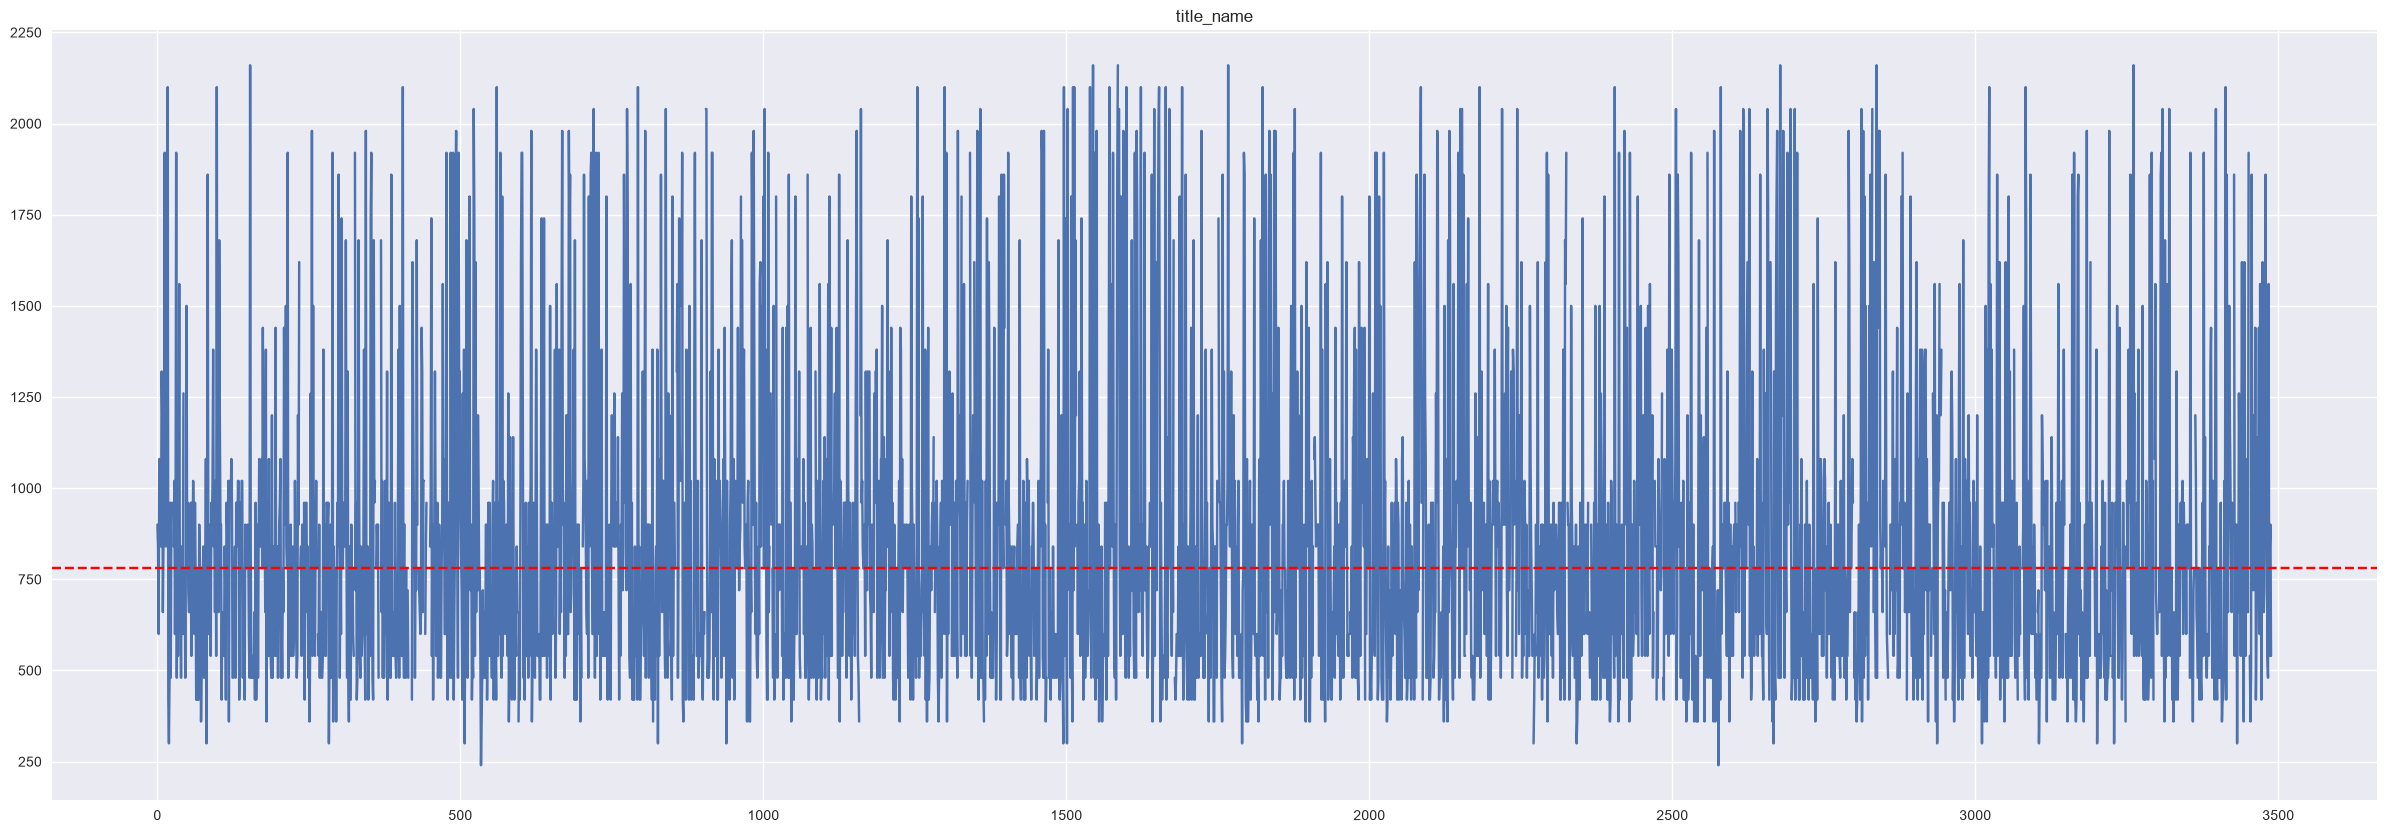

In [10]:
plt.figure(figsize=(30, 10))
matplotlib.style.use("seaborn-v0_8")
plt.plot(df["DurationOfPitch"])
plt.axhline(y=780, color='red', linestyle='--')
plt.title("title_name")
plt.show()

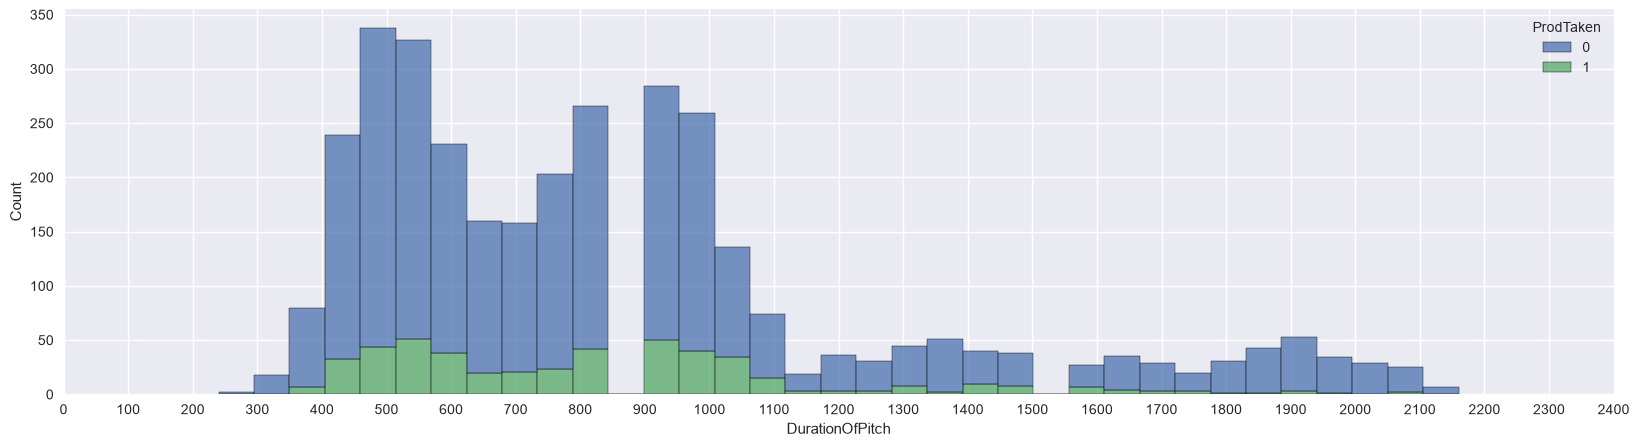

In [11]:
plt.figure(figsize=(20, 5))
sns.histplot(data=df, x='DurationOfPitch', hue='ProdTaken', multiple='stack')
plt.xticks(range(0, 2500, 100))
plt.show()

ボリュームゾーンは400〜1100秒（約7〜18分）

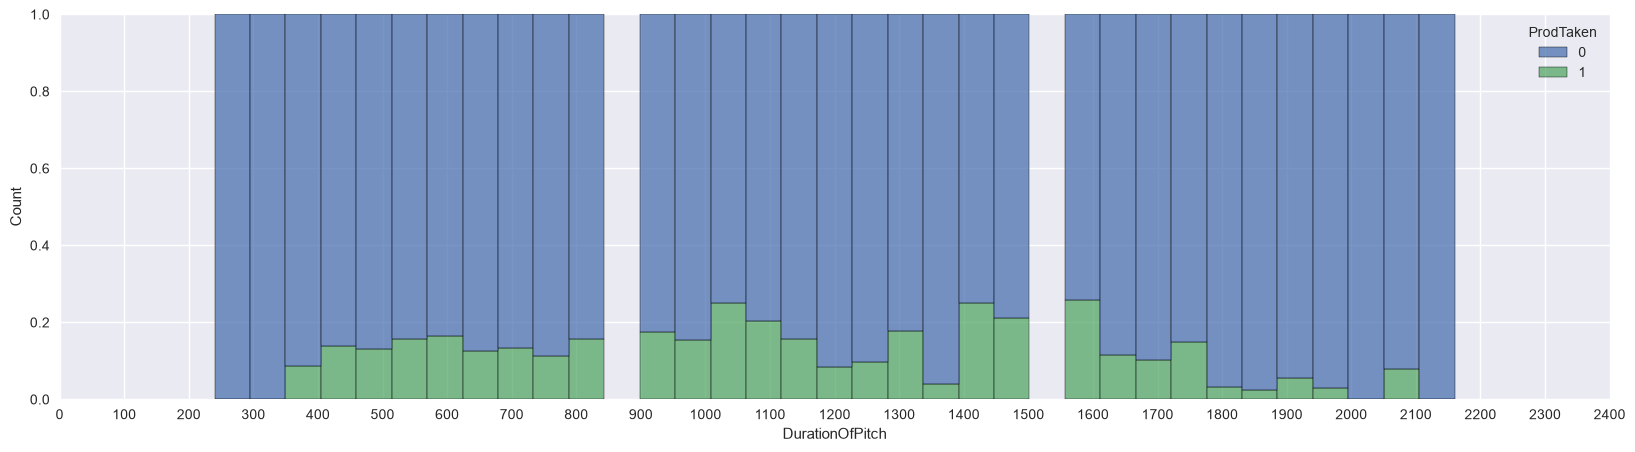

In [12]:
plt.figure(figsize=(20, 5))
sns.histplot(data=df, x='DurationOfPitch', hue='ProdTaken', multiple='fill')
plt.xticks(range(0, 2500, 100))
plt.show()

値を1にスケーリング

In [13]:
df["DurationOfPitch"]

0        900.0
1        840.0
2        600.0
3       1080.0
4       1020.0
         ...  
3484    1560.0
3485     540.0
3486     840.0
3487     900.0
3488     540.0
Name: DurationOfPitch, Length: 3489, dtype: float64

In [14]:
df

,id,Age,TypeofContact,CityTier,DurationOfPitch,Occupation,Gender,NumberOfPersonVisiting,NumberOfFollowups,ProductPitched,PreferredPropertyStar,NumberOfTrips,Passport,PitchSatisfactionScore,Designation,MonthlyIncome,customer_info,ProdTaken,Pitch_Unit
0,0,50歳,Self Enquiry,2,900.0,Large Business,male,1.0,4.0,Basic,3.0,5,1,4,Executive,253905.0,未婚 車未所持 子供なし,1,秒
1,1,56歳,Company Invited,1,840.0,Salaried,Male,1.0,4.0,Standard,3.0,2,1,4,Senior Manager,404475.0,"離婚済み,車あり,子供無し",0,分
2,2,NaN,Self Enquiry,1,600.0,Large Business,Female,1.0,3.0,Basic,3.0,4,0,4,Executive,278145.0,"結婚済み、自動車未所有,子供なし",1,分
3,3,三十七歳,Self Enquiry,2,1080.0,Small Business,female,1.0,3.0,Standard,4.0,1,0,5,Senior Manager,326805.0,離婚済み、車所持、子供無し,0,秒
4,4,48歳,Company Invited,3,1020.0,Small Business,female,1.0,3.0,Basic,4.0,4,0,4,Executive,258435.0,独身／車所持／無子,1,秒
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3484,3484,40歳,Self Enquiry,2,1560.0,Salaried,Male,2.0,3.0,Basic,3.0,3,0,1,Executive,258900.0,離婚済み 乗用車所持 子供なし,1,秒
3485,3485,40代,Self Enquiry,1,540.0,Large Business,Male,3.0,3.0,Basic,5.0,5,0,3,Executive,260415.0,結婚済み、車所持、子供2人,0,分
3486,3486,31歳,Self Enquiry,1,840.0,Small Business,FEMALE,3.0,2.0,Standard,3.0,5,0,4,Senior Manager,317340.0,独身／車所持／こども1人,0,秒
3487,3487,56歳,Company Invited,2,900.0,Salaried,Male,3.0,6.0,King,3.0,7,1,4,VP,527910.0,結婚済み、自動車未所有、子供2人,1,秒
